In [1]:
# Créditos: https://www.codificandobits.com/blog/tutorial-prediccion-de-acciones-en-la-bolsa-redes-lstm/

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [ ]:
# si tienen el archivo en local y lo quieren subir a Colab
from google.colab import files
files.upload()

In [2]:
# Funciones auxiliares

def graficar_predicciones(real, prediccion):
    plt.plot(real[len(real)-len(prediccion):],color='red', label='Valor real de la acción')
    plt.plot(prediccion, color='blue', label='Predicción de la acción')
    plt.ylim(1.1 * np.min(prediccion)/2, 1.1 * np.max(prediccion))
    plt.xlabel('Tiempo')
    plt.ylabel('Valor de la acción')
    plt.legend()
    plt.show()

In [3]:
tf.random.set_seed(4)

# Lectura de los datos

dataset = pd.read_csv('https://github.com/palasatenea66/DATASETS/raw/main/AAPL_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


In [4]:
dataset.columns


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Name'], dtype='object')

In [5]:
dataset.tail()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2017-12-22,174.68,175.42,174.50,175.01,16349444,AAPL
2017-12-26,170.80,171.47,169.68,170.57,33185536,AAPL
2017-12-27,170.10,170.78,169.71,170.60,21498213,AAPL
2017-12-28,171.00,171.85,170.48,171.08,16480187,AAPL
2017-12-29,170.52,170.59,169.22,169.23,25999922,AAPL


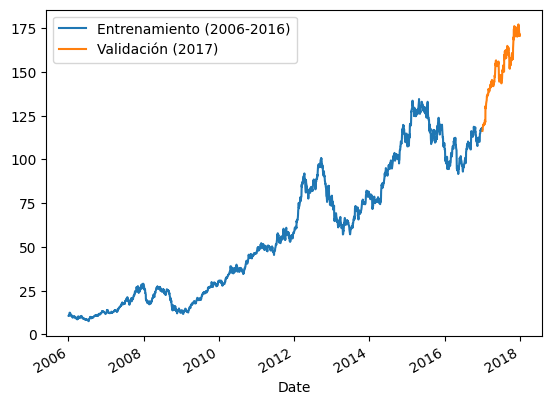

In [6]:
# Sets de entrenamiento y validación
# La LSTM se entrenará con datos de 2016 hacia atrás. La validación se hará con datos de 2017 en adelante.
# En ambos casos sólo se usará el valor más alto de la acción para cada día

set_entrenamiento = dataset[:'2016'].iloc[:,1:2]
set_validacion = dataset['2017':].iloc[:,1:2]

set_entrenamiento['High'].plot(legend=True)
set_validacion['High'].plot(legend=True)
plt.legend(['Entrenamiento (2006-2016)', 'Validación (2017)'])
plt.show()

# Normalización del set de entrenamiento
sc = MinMaxScaler(feature_range=(0,1))
set_entrenamiento_escalado = sc.fit_transform(set_entrenamiento)


In [7]:
set_validacion_escalado = sc.transform(set_validacion)

In [8]:
set_entrenamiento_escalado

array([[0.0245708 ],
       [0.02590959],
       [0.0247283 ],
       ...,
       [0.86990077],
       [0.86273429],
       [0.86344306]])

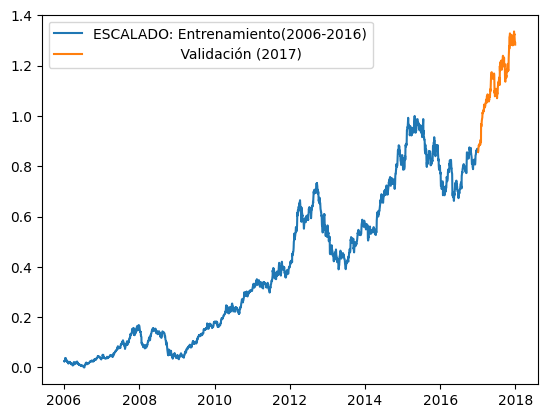

In [37]:
plt.plot(dataset[:'2016'].index, set_entrenamiento_escalado)
plt.plot(dataset['2017':].index, set_validacion_escalado)
plt.legend(['ESCALADO: Entrenamiento(2006-2016)', '                    Validación (2017)'])
plt.show()


In [11]:
# La red LSTM tendrá como entrada "time_step" datos consecutivos, y como salida 1 dato (la predicción a
# partir de esos "time_step" datos). Se conformará de esta forma el set de entrenamiento
time_step = 60
X_train = []
Y_train = []
m = len(set_entrenamiento_escalado)

for i in range(time_step,m):
    # X: bloques de "time_step" datos: 0-time_step, 1-time_step+1, 2-time_step+2, etc
    X_train.append(set_entrenamiento_escalado[i-time_step:i,0])

    # Y: el siguiente dato
    Y_train.append(set_entrenamiento_escalado[i,0])
X_train, Y_train = np.array(X_train), np.array(Y_train)

# Reshape X_train para que se ajuste al modelo en Keras
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [12]:
X_train

array([[[0.0245708 ],
        [0.02590959],
        [0.0247283 ],
        ...,
        [0.00952906],
        [0.00811151],
        [0.0107891 ]],

       [[0.02590959],
        [0.0247283 ],
        [0.02677587],
        ...,
        [0.00811151],
        [0.0107891 ],
        [0.01165538]],

       [[0.0247283 ],
        [0.02677587],
        [0.02732714],
        ...,
        [0.0107891 ],
        [0.01165538],
        [0.01204914]],

       ...,

       [[0.83076075],
        [0.84068357],
        [0.83556466],
        ...,
        [0.85800914],
        [0.85808789],
        [0.86816822]],

       [[0.84068357],
        [0.83556466],
        [0.84091983],
        ...,
        [0.85808789],
        [0.86816822],
        [0.86990077]],

       [[0.83556466],
        [0.84091983],
        [0.84265239],
        ...,
        [0.86816822],
        [0.86990077],
        [0.86273429]]])

In [13]:
X_train.shape

(2708, 60, 1)

In [14]:
Y_train.shape

(2708,)

In [15]:
# Red LSTM

dim_entrada = (X_train.shape[1],1)
dim_salida = 1
na = 50

modelo = Sequential()
modelo.add(LSTM(units=na, input_shape=dim_entrada))
modelo.add(Dense(units=dim_salida))
modelo.compile(optimizer='rmsprop', loss='mse')
modelo.fit(X_train,Y_train,epochs=20,batch_size=32)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0143
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.4916e-04
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 7.1222e-04
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.5751e-04
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 4.2471e-04
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 3.6791e-04
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 3.3994e-04
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 3.1980e-04
Epoch 9/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 3.0295e-04
Epoch 10/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 2.8880e-04
Epoch 11/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 2.7672e-04
Epoch 12/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.6418e-04
Epoch 13/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2.6712e-04
Epoch 14/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 2.6528e-04
Epoch 15/20
85/85 ━

In [16]:
# Validación (predicción del valor de las acciones)

x_test = set_validacion.values
x_test = sc.transform(x_test)

X_test = []
for i in range(time_step,len(x_test)):
    X_test.append(x_test[i-time_step:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

prediccion = modelo.predict(X_test)
prediccion = sc.inverse_transform(prediccion)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [17]:
prediccion

array([[140.6806 ],
       [141.19084],
       [141.52206],
       [141.71805],
       [142.04254],
       [142.42218],
       [142.45375],
       [142.3587 ],
       [142.17088],
       [141.85509],
       [141.26753],
       [140.84413],
       [140.37387],
       [140.0526 ],
       [139.80696],
       [139.88092],
       [139.91022],
       [140.29712],
       [140.88261],
       [141.29301],
       [141.50839],
       [141.70253],
       [142.60086],
       [143.54683],
       [144.13783],
       [144.48698],
       [145.20172],
       [146.97128],
       [148.67651],
       [149.76479],
       [150.59972],
       [151.78972],
       [152.71562],
       [153.21896],
       [153.14055],
       [152.66068],
       [152.35788],
       [152.2153 ],
       [152.15851],
       [151.91321],
       [151.75894],
       [151.60603],
       [151.53865],
       [151.4257 ],
       [151.12485],
       [151.44414],
       [151.4539 ],
       [151.83162],
       [152.18723],
       [152.36272],


In [18]:
prediccion.shape

(191, 1)

In [19]:
set_validacion.shape

(251, 1)

In [20]:
set_validacion.index

DatetimeIndex(['2017-01-03', '2017-01-04', '2017-01-05', '2017-01-06',
               '2017-01-09', '2017-01-10', '2017-01-11', '2017-01-12',
               '2017-01-13', '2017-01-17',
               ...
               '2017-12-15', '2017-12-18', '2017-12-19', '2017-12-20',
               '2017-12-21', '2017-12-22', '2017-12-26', '2017-12-27',
               '2017-12-28', '2017-12-29'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)

In [21]:
fechas=list(set_validacion.index)
fechas

[Timestamp('2017-01-03 00:00:00'),
 Timestamp('2017-01-04 00:00:00'),
 Timestamp('2017-01-05 00:00:00'),
 Timestamp('2017-01-06 00:00:00'),
 Timestamp('2017-01-09 00:00:00'),
 Timestamp('2017-01-10 00:00:00'),
 Timestamp('2017-01-11 00:00:00'),
 Timestamp('2017-01-12 00:00:00'),
 Timestamp('2017-01-13 00:00:00'),
 Timestamp('2017-01-17 00:00:00'),
 Timestamp('2017-01-18 00:00:00'),
 Timestamp('2017-01-19 00:00:00'),
 Timestamp('2017-01-20 00:00:00'),
 Timestamp('2017-01-23 00:00:00'),
 Timestamp('2017-01-24 00:00:00'),
 Timestamp('2017-01-25 00:00:00'),
 Timestamp('2017-01-26 00:00:00'),
 Timestamp('2017-01-27 00:00:00'),
 Timestamp('2017-01-30 00:00:00'),
 Timestamp('2017-01-31 00:00:00'),
 Timestamp('2017-02-01 00:00:00'),
 Timestamp('2017-02-02 00:00:00'),
 Timestamp('2017-02-03 00:00:00'),
 Timestamp('2017-02-06 00:00:00'),
 Timestamp('2017-02-07 00:00:00'),
 Timestamp('2017-02-08 00:00:00'),
 Timestamp('2017-02-09 00:00:00'),
 Timestamp('2017-02-10 00:00:00'),
 Timestamp('2017-02-

In [22]:
fecha_corta=fechas[60:]
fecha_corta

[Timestamp('2017-03-30 00:00:00'),
 Timestamp('2017-03-31 00:00:00'),
 Timestamp('2017-04-03 00:00:00'),
 Timestamp('2017-04-04 00:00:00'),
 Timestamp('2017-04-05 00:00:00'),
 Timestamp('2017-04-06 00:00:00'),
 Timestamp('2017-04-07 00:00:00'),
 Timestamp('2017-04-10 00:00:00'),
 Timestamp('2017-04-11 00:00:00'),
 Timestamp('2017-04-12 00:00:00'),
 Timestamp('2017-04-13 00:00:00'),
 Timestamp('2017-04-17 00:00:00'),
 Timestamp('2017-04-18 00:00:00'),
 Timestamp('2017-04-19 00:00:00'),
 Timestamp('2017-04-20 00:00:00'),
 Timestamp('2017-04-21 00:00:00'),
 Timestamp('2017-04-24 00:00:00'),
 Timestamp('2017-04-25 00:00:00'),
 Timestamp('2017-04-26 00:00:00'),
 Timestamp('2017-04-27 00:00:00'),
 Timestamp('2017-04-28 00:00:00'),
 Timestamp('2017-05-01 00:00:00'),
 Timestamp('2017-05-02 00:00:00'),
 Timestamp('2017-05-03 00:00:00'),
 Timestamp('2017-05-04 00:00:00'),
 Timestamp('2017-05-05 00:00:00'),
 Timestamp('2017-05-08 00:00:00'),
 Timestamp('2017-05-09 00:00:00'),
 Timestamp('2017-05-

In [23]:
df_pred=pd.DataFrame(prediccion, columns=['prediccion apple'], index=fecha_corta)
df_pred

,prediccion apple
2017-03-30,140.680603
2017-03-31,141.190842
2017-04-03,141.522064
2017-04-04,141.718048
2017-04-05,142.042542
...,...
2017-12-22,171.581360
2017-12-26,171.717941
2017-12-27,170.770172
2017-12-28,169.783142


In [24]:
lis= [i for i in range(60)]
lis

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59]

In [25]:
val_corto=set_validacion.drop(set_validacion.index[[i for i in range(60)]])
val_corto

,High
Date,
2017-03-30,144.50
2017-03-31,144.27
2017-04-03,144.12
2017-04-04,144.89
2017-04-05,145.46
...,...
2017-12-22,175.42
2017-12-26,171.47
2017-12-27,170.78


In [26]:
error_porc = 100*(val_corto.values - df_pred.values)/val_corto.values
error=pd.DataFrame(error_porc, index=fecha_corta, columns=['dif %'])
error

,dif %
2017-03-30,2.643181
2017-03-31,2.134303
2017-04-03,1.802620
2017-04-04,2.189214
2017-04-05,2.349415
...,...
2017-12-22,2.188257
2017-12-26,-0.144597
2017-12-27,0.005755
2017-12-28,1.202710


<Axes: >

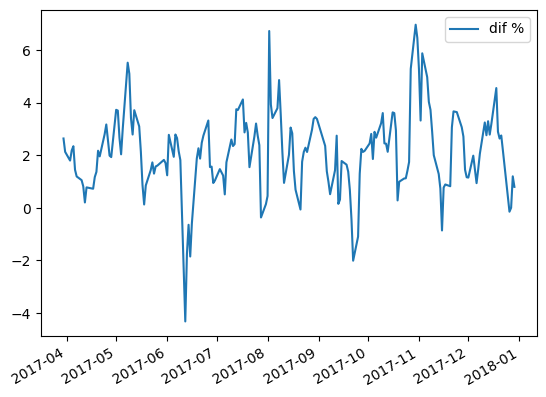

In [27]:
error.plot(legend=True)

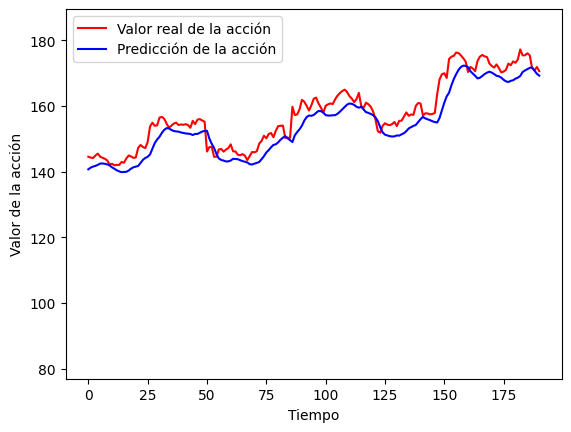

In [28]:
# Graficar resultados
graficar_predicciones(set_validacion.values,prediccion)


In [29]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,904 (81.66 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,453 (40.84 KB)